### Imports

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
file_path = Path(r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\df_BA_TotActPwr_BESS_AC_Panel1_imp.parquet")

df = pd.read_parquet(file_path)

print("Shape:", df.shape)
df.head()

Shape: (33120, 38)


,BA_TotActPwr_BESS_AC_Panel1,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum,dayofweek,is_weekend,hour,month,dayofmonth,...,BA_TotActPwr_BESS_AC_Panel1_roll_mean_6,BA_TotActPwr_BESS_AC_Panel1_roll_mean_12,BA_TotActPwr_BESS_AC_Panel1_roll_mean_36,BA_TotActPwr_BESS_AC_Panel1_roll_mean_288,BA_TotActPwr_BESS_AC_Panel1_roll_std_12,BA_TotActPwr_BESS_AC_Panel1_roll_std_36,BA_TotActPwr_BESS_AC_Panel1_roll_min_12,BA_TotActPwr_BESS_AC_Panel1_roll_max_12,BA_TotActPwr_BESS_AC_Panel1_trend_1h,BA_TotActPwr_BESS_AC_Panel1_trend_24h
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-17 00:00:00,0.174,84.3,139.0,-1.3,87.5,4,0,0,10,17,...,0.783667,0.709750,0.467361,1.886288,0.364415,0.362976,0.173,1.34,0.289,-0.870
2025-10-17 00:05:00,0.739,84.1,139.0,-1.3,87.7,4,0,0,10,17,...,0.757333,0.709833,0.438250,1.882267,0.364281,0.342152,0.173,1.34,0.001,-1.461
2025-10-17 00:10:00,0.467,84.1,139.0,-0.9,87.9,4,0,0,10,17,...,0.754667,0.757000,0.424528,1.879156,0.322726,0.318452,0.174,1.34,-0.014,-1.476
2025-10-17 00:15:00,0.866,84.0,139.0,-0.6,87.9,4,0,0,10,17,...,0.656667,0.733167,0.432861,1.873087,0.333431,0.315432,0.174,1.34,-0.428,-2.042
2025-10-17 00:20:00,1.624,84.0,139.0,-1.0,88.0,4,0,0,10,17,...,0.674667,0.730750,0.452194,1.867382,0.332254,0.320154,0.174,1.34,-0.191,-1.347


In [12]:
df.columns.tolist()

['BA_TotActPwr_BESS_AC_Panel1',
 'BA_Soc',
 'PV_WS_AirTemp',
 'PV_WS_Radiation',
 'PV_WS_RelHum',
 'dayofweek',
 'is_weekend',
 'hour',
 'month',
 'dayofmonth',
 'minute_of_day',
 'sin_tod',
 'cos_tod',
 'sin_dow',
 'cos_dow',
 'is_business_hours',
 'BA_TotActPwr_BESS_AC_Panel1_lag_1',
 'BA_TotActPwr_BESS_AC_Panel1_lag_2',
 'BA_TotActPwr_BESS_AC_Panel1_lag_3',
 'BA_TotActPwr_BESS_AC_Panel1_lag_6',
 'BA_TotActPwr_BESS_AC_Panel1_lag_12',
 'BA_TotActPwr_BESS_AC_Panel1_lag_24',
 'BA_TotActPwr_BESS_AC_Panel1_lag_36',
 'BA_TotActPwr_BESS_AC_Panel1_lag_48',
 'BA_TotActPwr_BESS_AC_Panel1_lag_72',
 'BA_TotActPwr_BESS_AC_Panel1_lag_144',
 'BA_TotActPwr_BESS_AC_Panel1_lag_288',
 'BA_TotActPwr_BESS_AC_Panel1_lag_576',
 'BA_TotActPwr_BESS_AC_Panel1_roll_mean_6',
 'BA_TotActPwr_BESS_AC_Panel1_roll_mean_12',
 'BA_TotActPwr_BESS_AC_Panel1_roll_mean_36',
 'BA_TotActPwr_BESS_AC_Panel1_roll_mean_288',
 'BA_TotActPwr_BESS_AC_Panel1_roll_std_12',
 'BA_TotActPwr_BESS_AC_Panel1_roll_std_36',
 'BA_TotActPwr_B

In [16]:
print(isinstance(df.index, pd.DatetimeIndex))  # should be True
print(df.index.is_monotonic_increasing)        # should be True
print(df.index.has_duplicates)                 # should be False

True
True
False


In [17]:
# =========================================================
# 1. DEFINE TARGET AND FEATURES
# =========================================================
# Change this to your actual target load column
target_col = "BA_TotActPwr_BESS_AC_Panel1"

# Safer: explicitly define feature columns if possible
# For now, this takes all columns except the target
feature_cols = [c for c in df.columns if c != target_col]

print("Target column:", target_col)
print("Number of features:", len(feature_cols))

# =========================================================
# 2. HORIZONS FOR 5-MIN DATA
# =========================================================

HORIZONS = {
    "1h": 12,
    "1d": 288
}

# =========================================================
# 3. METRICS
# =========================================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

# =========================================================
# 4. MAIN FUNCTION
# =========================================================
def train_rf_with_timeseries_split(
    df,
    target_col,
    feature_cols,
    horizon_steps,
    test_ratio=0.20,
    n_splits=5,
    random_state=42
):
    data = df.copy()

    # Create future target
    data["target_future"] = data[target_col].shift(-horizon_steps)

    # Drop rows where future target is missing
    data = data.dropna(subset=["target_future"])

    # Optional: if your features still have NaN, remove those rows for Random Forest
    data = data.dropna(subset=feature_cols)

    X = data[feature_cols]
    y = data["target_future"]

    # -----------------------------
    # Chronological final split
    # -----------------------------
    n_total = len(data)
    n_test = int(n_total * test_ratio)
    n_train = n_total - n_test

    X_train = X.iloc[:n_train]
    X_test  = X.iloc[n_train:]

    y_train = y.iloc[:n_train]
    y_test  = y.iloc[n_train:]

    print("\n" + "="*70)
    print(f"Horizon steps: {horizon_steps}")
    print(f"Total samples : {n_total}")
    print(f"Train samples : {len(X_train)}")
    print(f"Test samples  : {len(X_test)}")
    print(f"Train period  : {X_train.index.min()}  -->  {X_train.index.max()}")
    print(f"Test period   : {X_test.index.min()}  -->  {X_test.index.max()}")

    # -----------------------------
    # TimeSeriesSplit on TRAIN only
    # -----------------------------
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=random_state
        )

        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        metrics = calc_metrics(y_val.values, y_val_pred)

        fold_results.append({
            "fold": fold,
            "train_start": X_tr.index.min(),
            "train_end": X_tr.index.max(),
            "val_start": X_val.index.min(),
            "val_end": X_val.index.max(),
            **metrics
        })

        print(
            f"Fold {fold}: "
            f"MAE={metrics['MAE']:.4f}, "
            f"RMSE={metrics['RMSE']:.4f}, "
            f"MAPE={metrics['MAPE_%']:.2f}%, "
            f"R2={metrics['R2']:.4f}"
        )

    cv_results = pd.DataFrame(fold_results)

    print("\nAverage CV metrics:")
    print(cv_results[["MAE", "RMSE", "MAPE_%", "R2"]].mean())

    # -----------------------------
    # Final model on full training set
    # -----------------------------
    final_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=random_state
    )

    final_model.fit(X_train, y_train)
    y_test_pred = final_model.predict(X_test)

    test_metrics = calc_metrics(y_test.values, y_test_pred)

    print("\nFinal Test Metrics:")
    print(test_metrics)

    predictions = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred
    }, index=y_test.index)

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    return {
        "model": final_model,
        "cv_results": cv_results,
        "test_metrics": test_metrics,
        "predictions": predictions,
        "feature_importance": feature_importance
    }


Target column: BA_TotActPwr_BESS_AC_Panel1
Number of features: 37


In [18]:
# =========================================================
# 5. RUN FOR 1-HOUR AHEAD
# =========================================================
results_1h = train_rf_with_timeseries_split(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1h"],
    test_ratio=0.20,
    n_splits=5
)



Horizon steps: 12
Total samples : 33108
Train samples : 26487
Test samples  : 6621
Train period  : 2025-10-17 00:00:00  -->  2026-01-16 23:10:00
Test period   : 2026-01-16 23:15:00  -->  2026-02-08 22:55:00
Fold 1: MAE=0.7000, RMSE=1.1229, MAPE=121.86%, R2=0.5083
Fold 2: MAE=0.6455, RMSE=1.1340, MAPE=109.98%, R2=0.5203
Fold 3: MAE=0.6469, RMSE=0.9652, MAPE=103.27%, R2=0.6031
Fold 4: MAE=0.6037, RMSE=0.9940, MAPE=107.08%, R2=0.6795
Fold 5: MAE=0.4341, RMSE=0.7122, MAPE=84.70%, R2=0.7800

Average CV metrics:
MAE         0.606058
RMSE        0.985639
MAPE_%    105.377621
R2          0.618259
dtype: float64

Final Test Metrics:
{'MAE': 0.6858534885045158, 'RMSE': np.float64(1.3294665495341338), 'MAPE_%': np.float64(75.86821175160512), 'R2': 0.5296012710396624}


In [19]:

# =========================================================
# 6. RUN FOR 1-DAY AHEAD
# =========================================================
results_1d = train_rf_with_timeseries_split(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1d"],
    test_ratio=0.20,
    n_splits=5
)



Horizon steps: 288
Total samples : 32832
Train samples : 26266
Test samples  : 6566
Train period  : 2025-10-17 00:00:00  -->  2026-01-16 04:45:00
Test period   : 2026-01-16 04:50:00  -->  2026-02-07 23:55:00
Fold 1: MAE=1.3087, RMSE=1.6995, MAPE=350.64%, R2=-0.1777
Fold 2: MAE=1.1205, RMSE=1.5472, MAPE=268.04%, R2=0.1586
Fold 3: MAE=1.0944, RMSE=1.4508, MAPE=208.26%, R2=0.1172
Fold 4: MAE=1.1590, RMSE=1.5732, MAPE=278.00%, R2=0.1639
Fold 5: MAE=1.1602, RMSE=1.4374, MAPE=389.02%, R2=0.0994

Average CV metrics:
MAE         1.168571
RMSE        1.541625
MAPE_%    298.790690
R2          0.072284
dtype: float64

Final Test Metrics:
{'MAE': 1.1660644857491718, 'RMSE': np.float64(1.7121665327524882), 'MAPE_%': np.float64(191.21220719684985), 'R2': 0.22602733786461493}


In [20]:

# =========================================================
# 7. VIEW RESULTS
# =========================================================
print("\n1-Hour Ahead Test Metrics")
print(results_1h["test_metrics"])

print("\n1-Day Ahead Test Metrics")
print(results_1d["test_metrics"])

print("\nTop 10 Features for 1-Hour Ahead")
print(results_1h["feature_importance"].head(10))

print("\nTop 10 Features for 1-Day Ahead")
print(results_1d["feature_importance"].head(10))


1-Hour Ahead Test Metrics
{'MAE': 0.6858534885045158, 'RMSE': np.float64(1.3294665495341338), 'MAPE_%': np.float64(75.86821175160512), 'R2': 0.5296012710396624}

1-Day Ahead Test Metrics
{'MAE': 1.1660644857491718, 'RMSE': np.float64(1.7121665327524882), 'MAPE_%': np.float64(191.21220719684985), 'R2': 0.22602733786461493}

Top 10 Features for 1-Hour Ahead
                                      feature  importance
15          BA_TotActPwr_BESS_AC_Panel1_lag_1    0.381665
11                                    cos_tod    0.101654
32    BA_TotActPwr_BESS_AC_Panel1_roll_std_36    0.073146
29   BA_TotActPwr_BESS_AC_Panel1_roll_mean_36    0.043648
33    BA_TotActPwr_BESS_AC_Panel1_roll_min_12    0.038912
30  BA_TotActPwr_BESS_AC_Panel1_roll_mean_288    0.038908
1                               PV_WS_AirTemp    0.036511
2                             PV_WS_Radiation    0.032065
0                                      BA_Soc    0.025432
3                                PV_WS_RelHum    0.020201

To

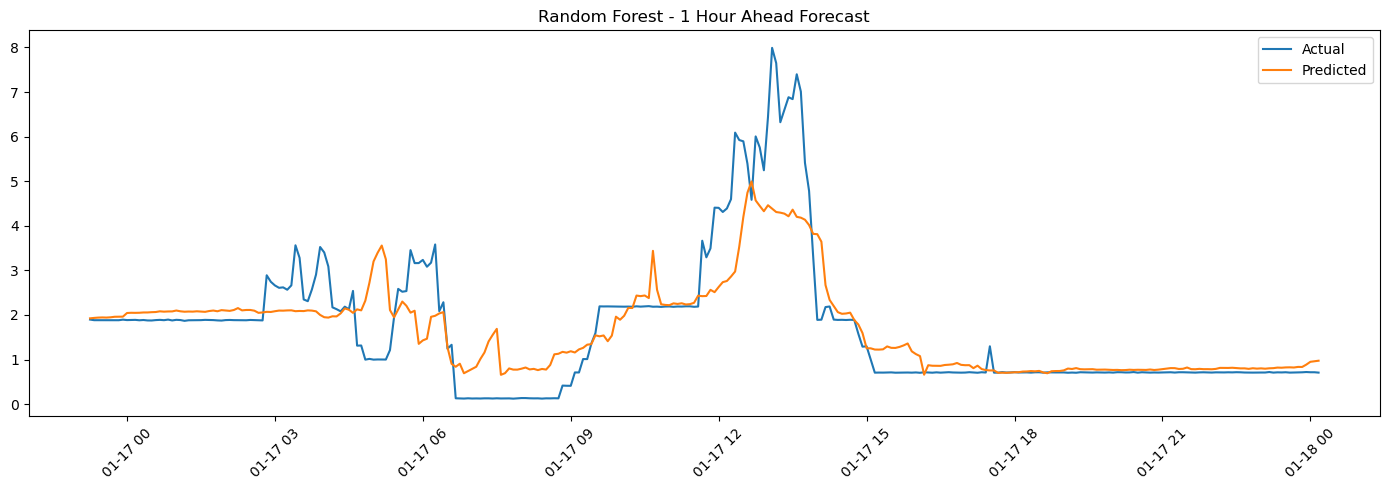

In [21]:
import matplotlib.pyplot as plt

pred_1h = results_1h["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1h.index[:300], pred_1h["y_true"].iloc[:300], label="Actual")
plt.plot(pred_1h.index[:300], pred_1h["y_pred"].iloc[:300], label="Predicted")
plt.legend()
plt.title("Random Forest - 1 Hour Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

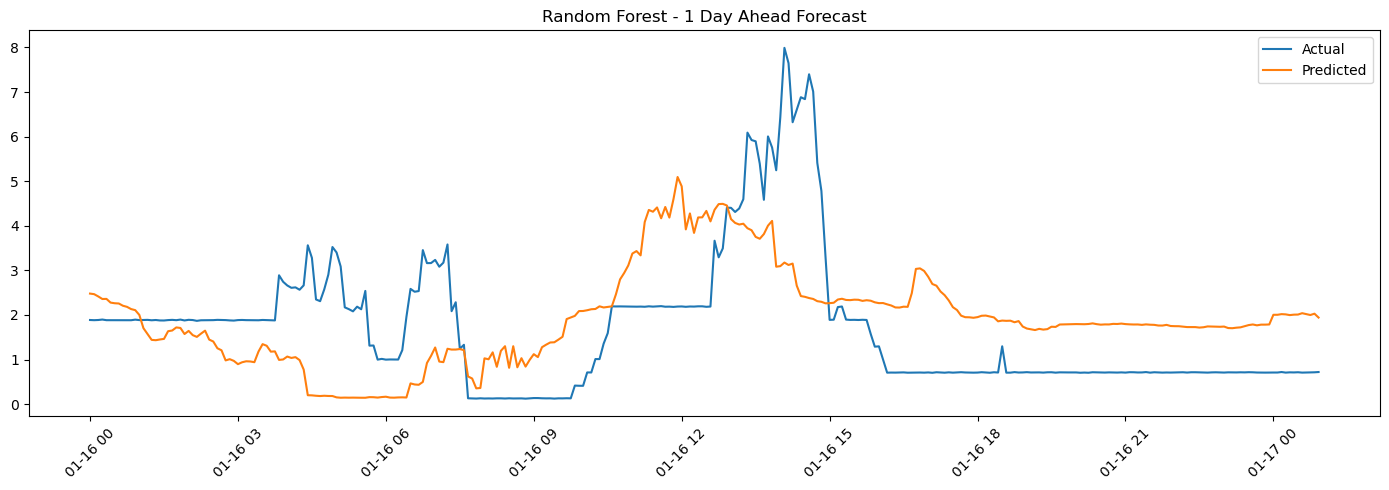

In [33]:
pred_1d = results_1d["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1d.index[:300], pred_1d["y_true"].iloc[:300], label="Actual")
plt.plot(pred_1d.index[:300], pred_1d["y_pred"].iloc[:300], label="Predicted")
plt.legend()
plt.title("Random Forest - 1 Day Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
file_path = Path(r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\df_BU_TotActPwr_Academy_imp.parquet")

df_BU_TotActPwr_Academy_imp = pd.read_parquet(file_path)

print("Shape:", df_BU_TotActPwr_Academy_imp.shape)
df_BU_TotActPwr_Academy_imp.head()

Shape: (33408, 29)


,BU_TotActPwr_Academy,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum,dayofweek,is_weekend,hour,month,dayofmonth,...,BU_TotActPwr_Academy_lag_36,BU_TotActPwr_Academy_lag_72,BU_TotActPwr_Academy_lag_144,BU_TotActPwr_Academy_lag_288,BU_TotActPwr_Academy_roll_mean_12,BU_TotActPwr_Academy_roll_mean_36,BU_TotActPwr_Academy_roll_mean_72,BU_TotActPwr_Academy_roll_mean_288,BU_TotActPwr_Academy_roll_std_12,BU_TotActPwr_Academy_roll_std_36
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-16 00:00:00,3.705,83.7,131.0,-4.2,84.5,3,0,0,10,16,...,4.416,6.587,12.224,4.148,4.293000,4.308306,4.242514,6.826337,0.373116,0.517125
2025-10-16 00:05:00,3.750,83.6,131.0,-4.2,84.9,3,0,0,10,16,...,4.048,6.042,9.335,3.631,4.204750,4.288556,4.202486,6.824799,0.376807,0.526389
2025-10-16 00:10:00,3.724,83.5,130.0,-4.1,85.1,3,0,0,10,16,...,3.956,4.788,9.423,3.572,4.178667,4.280278,4.170653,6.825212,0.397762,0.532586
2025-10-16 00:15:00,3.773,83.4,129.0,-4.0,85.2,3,0,0,10,16,...,4.109,3.147,12.446,3.663,4.148583,4.273833,4.155875,6.825740,0.418596,0.537998
2025-10-16 00:20:00,3.868,83.4,129.0,-3.9,85.4,3,0,0,10,16,...,4.113,4.936,9.296,3.610,4.122500,4.264500,4.164569,6.826122,0.432375,0.543823


In [35]:
print(isinstance(df_BU_TotActPwr_Academy_imp.index, pd.DatetimeIndex))  # should be True
print(df_BU_TotActPwr_Academy_imp.index.is_monotonic_increasing)        # should be True
print(df_BU_TotActPwr_Academy_imp.index.has_duplicates)                 # should be False

True
True
False


In [36]:
# =========================================================
# 1. DEFINE TARGET AND FEATURES
# =========================================================
# Change this to your actual target load column
target_col = "BU_TotActPwr_Academy"

# Safer: explicitly define feature columns if possible
# For now, this takes all columns except the target
feature_cols = [c for c in df_BU_TotActPwr_Academy_imp.columns if c != target_col]

print("Target column:", target_col)
print("Number of features:", len(feature_cols))

# =========================================================
# 2. HORIZONS FOR 5-MIN DATA
# =========================================================

HORIZONS = {
    "1h": 12,
    "1d": 288
}

# =========================================================
# 3. METRICS
# =========================================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

# =========================================================
# 4. MAIN FUNCTION
# =========================================================
def train_rf_with_timeseries_split(
    df_BU_TotActPwr_Academy_imp,
    target_col,
    feature_cols,
    horizon_steps,
    test_ratio=0.20,
    n_splits=5,
    random_state=42
):
    data = df_BU_TotActPwr_Academy_imp.copy()

    # Create future target
    data["target_future"] = data[target_col].shift(-horizon_steps)

    # Drop rows where future target is missing
    data = data.dropna(subset=["target_future"])

    # Optional: if your features still have NaN, remove those rows for Random Forest
    data = data.dropna(subset=feature_cols)

    X = data[feature_cols]
    y = data["target_future"]

    # -----------------------------
    # Chronological final split
    # -----------------------------
    n_total = len(data)
    n_test = int(n_total * test_ratio)
    n_train = n_total - n_test

    X_train = X.iloc[:n_train]
    X_test  = X.iloc[n_train:]

    y_train = y.iloc[:n_train]
    y_test  = y.iloc[n_train:]

    print("\n" + "="*70)
    print(f"Horizon steps: {horizon_steps}")
    print(f"Total samples : {n_total}")
    print(f"Train samples : {len(X_train)}")
    print(f"Test samples  : {len(X_test)}")
    print(f"Train period  : {X_train.index.min()}  -->  {X_train.index.max()}")
    print(f"Test period   : {X_test.index.min()}  -->  {X_test.index.max()}")

    # -----------------------------
    # TimeSeriesSplit on TRAIN only
    # -----------------------------
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=random_state
        )

        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        metrics = calc_metrics(y_val.values, y_val_pred)

        fold_results.append({
            "fold": fold,
            "train_start": X_tr.index.min(),
            "train_end": X_tr.index.max(),
            "val_start": X_val.index.min(),
            "val_end": X_val.index.max(),
            **metrics
        })

        print(
            f"Fold {fold}: "
            f"MAE={metrics['MAE']:.4f}, "
            f"RMSE={metrics['RMSE']:.4f}, "
            f"MAPE={metrics['MAPE_%']:.2f}%, "
            f"R2={metrics['R2']:.4f}"
        )

    cv_results = pd.DataFrame(fold_results)

    print("\nAverage CV metrics:")
    print(cv_results[["MAE", "RMSE", "MAPE_%", "R2"]].mean())

    # -----------------------------
    # Final model on full training set
    # -----------------------------
    final_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=random_state
    )

    final_model.fit(X_train, y_train)
    y_test_pred = final_model.predict(X_test)

    test_metrics = calc_metrics(y_test.values, y_test_pred)

    print("\nFinal Test Metrics:")
    print(test_metrics)

    predictions = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred
    }, index=y_test.index)

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    return {
        "model": final_model,
        "cv_results": cv_results,
        "test_metrics": test_metrics,
        "predictions": predictions,
        "feature_importance": feature_importance
    }


Target column: BU_TotActPwr_Academy
Number of features: 28


In [37]:
# =========================================================
# 5. RUN FOR 1-HOUR AHEAD
# =========================================================
results_1h = train_rf_with_timeseries_split(
    df_BU_TotActPwr_Academy_imp=df_BU_TotActPwr_Academy_imp,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1h"],
    test_ratio=0.20,
    n_splits=5
)



Horizon steps: 12
Total samples : 33396
Train samples : 26717
Test samples  : 6679
Train period  : 2025-10-16 00:00:00  -->  2026-01-16 18:20:00
Test period   : 2026-01-16 18:25:00  -->  2026-02-08 22:55:00
Fold 1: MAE=1.2669, RMSE=1.7940, MAPE=23.70%, R2=0.7718
Fold 2: MAE=1.6290, RMSE=2.5227, MAPE=19.17%, R2=0.7700
Fold 3: MAE=1.6426, RMSE=2.6222, MAPE=17.96%, R2=0.8055
Fold 4: MAE=1.3729, RMSE=2.1880, MAPE=19.35%, R2=0.8082
Fold 5: MAE=1.3927, RMSE=2.4110, MAPE=17.66%, R2=0.8434

Average CV metrics:
MAE        1.460808
RMSE       2.307598
MAPE_%    19.569536
R2         0.799781
dtype: float64

Final Test Metrics:
{'MAE': 1.6205131927970973, 'RMSE': np.float64(2.6968983818607812), 'MAPE_%': np.float64(18.591049558851065), 'R2': 0.8440715746194092}


In [38]:

# =========================================================
# 6. RUN FOR 1-DAY AHEAD
# =========================================================
results_1d = train_rf_with_timeseries_split(
    df_BU_TotActPwr_Academy_imp=df_BU_TotActPwr_Academy_imp,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1d"],
    test_ratio=0.20,
    n_splits=5
)



Horizon steps: 288
Total samples : 33120
Train samples : 26496
Test samples  : 6624
Train period  : 2025-10-16 00:00:00  -->  2026-01-15 23:55:00
Test period   : 2026-01-16 00:00:00  -->  2026-02-07 23:55:00
Fold 1: MAE=1.4337, RMSE=1.9699, MAPE=27.91%, R2=0.7283
Fold 2: MAE=2.1721, RMSE=3.2968, MAPE=24.91%, R2=0.6139
Fold 3: MAE=1.9247, RMSE=2.9284, MAPE=22.66%, R2=0.7567
Fold 4: MAE=1.7388, RMSE=2.5887, MAPE=23.81%, R2=0.7403
Fold 5: MAE=2.2600, RMSE=3.7552, MAPE=29.48%, R2=0.6175

Average CV metrics:
MAE        1.905867
RMSE       2.907801
MAPE_%    25.752471
R2         0.691337
dtype: float64

Final Test Metrics:
{'MAE': 2.242166342921226, 'RMSE': np.float64(3.5487299721787977), 'MAPE_%': np.float64(26.281934752867215), 'R2': 0.7313380332182442}


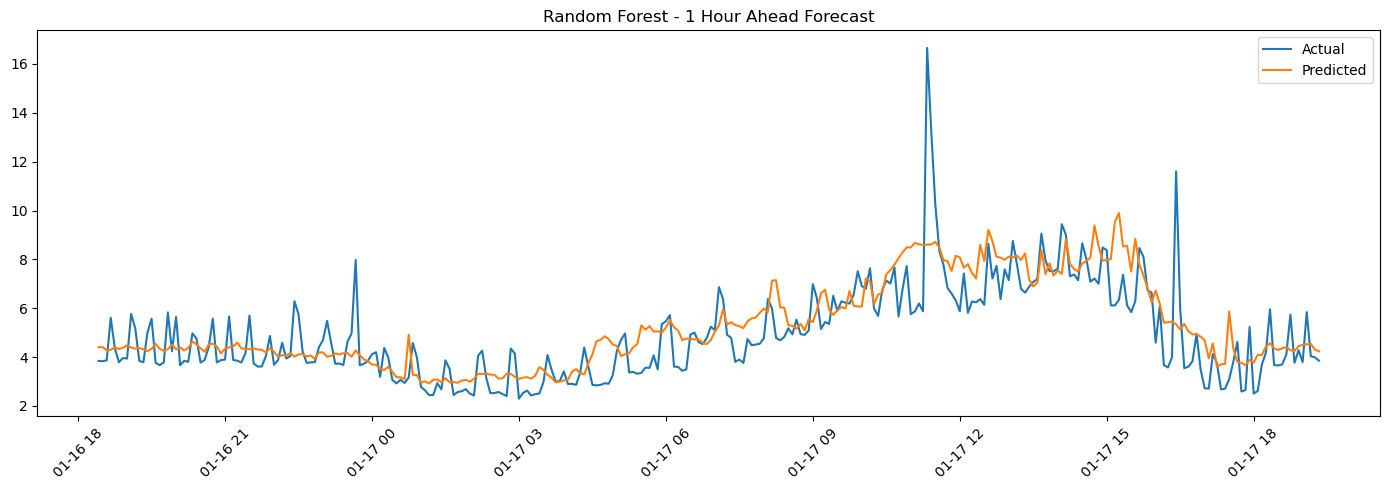

In [40]:
import matplotlib.pyplot as plt

pred_1h = results_1h["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1h.index[:300], pred_1h["y_true"].iloc[:300], label="Actual")
plt.plot(pred_1h.index[:300], pred_1h["y_pred"].iloc[:300], label="Predicted")
plt.legend()
plt.title("Random Forest - 1 Hour Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

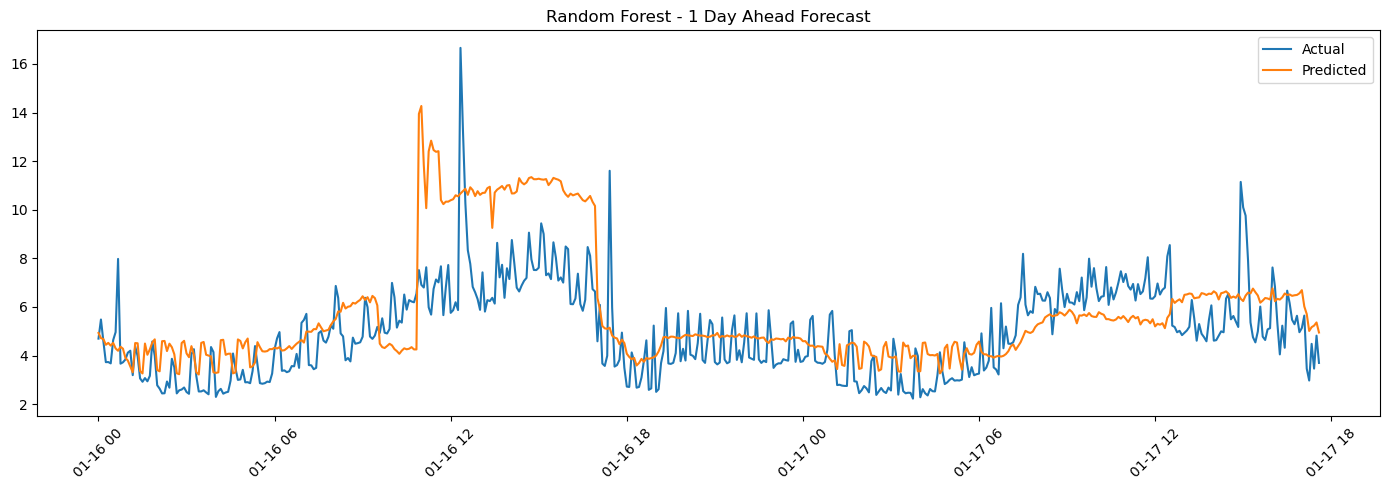

In [41]:
pred_1d = results_1d["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1d.index[:500], pred_1d["y_true"].iloc[:500], label="Actual")
plt.plot(pred_1d.index[:500], pred_1d["y_pred"].iloc[:500], label="Predicted")
plt.legend()
plt.title("Random Forest - 1 Day Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()